# **Convolutional Autoencoder for Speckle Noise Elimination**

An Autoencoder (AE) is a neural network that learns to compress and reconstruct data in an unsupervised manner. Its architecture is divided into two symmetrical parts Encoder and Decoder. 

### Encoder
Map the entrance $\mathbf{x} \in \mathbb{R}^P$ o a compressed latent rerpesentation: $$\mathbf{z} = g_\phi(\mathbf{x}), \quad \mathbf{z} \in \mathbb{R}^M, \quad M \ll P$$

### Decoder
Reconstruct the original input from the latent representation:

$$\hat{\mathbf{x}} = h_\theta(\mathbf{z})$$

### Loss Function
The parameters $\{\phi, \theta\}$ are optimized by minimizing reconstruction loss:

$$\mathcal{L} = \frac{1}{N} \sum_{i=1}^{N} \| \mathbf{x}_i - h_\theta(g_\phi(\mathbf{x}_i)) \|^2$$

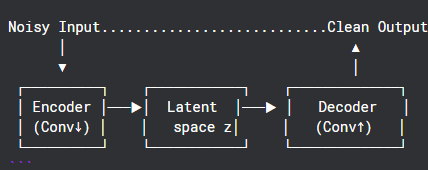


```

# **Speckle Noise**

Speckle noise is a type of multiplicative noise that appears in radar, ultrasound, and optical coherence system images. Unlike additive Gaussian noise, speckle is modeled as:

$$\mathbf{x}_{\text{noisy}} = \mathbf{x}_{\text{clean}} \cdot \mathbf{n}$$

where $\mathbf{n}$ follows a Gamma distribution or can be approximated as:

$$\mathbf{x}_{\text{noisy}} = \mathbf{x}_{\text{clean}} + \mathbf{x}_{\text{clean}} \cdot \mathcal{U}(0, \sigma^2)$$

**Main characteristics:**
- It is multiplicative: brighter regions have more noise.

- It gives the image a grainy appearance.

- It is more difficult to remove than additive Gaussian noise.

# **Import libraries**

In [5]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from PIL import Image
from pathlib import Path
from tqdm.notebook import tqdm
import shutil


import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
from torchvision.utils import make_grid

# **Loading the Dataset from Kaggle**

In [6]:
# Dataset paths in Kaggle 
BASE_PATH = Path('/kaggle/input/datasets/goutham1208/multi-noises-for-image-denoising')


# Explore the dataset structure
print("BASE_PATH exists:", BASE_PATH.exists())
print("BASE_PATH:", BASE_PATH)

print("\nImmediate contents:")
for item in BASE_PATH.iterdir():
    print("-", item)

BASE_PATH exists: True
BASE_PATH: /kaggle/input/datasets/goutham1208/multi-noises-for-image-denoising

Immediate contents:
- /kaggle/input/datasets/goutham1208/multi-noises-for-image-denoising/dataset


In [8]:
# ── Identify clean and noisy image folders 
def find_image_folders(base_path):
    """Automatically search for folders containing clean and speckle-noisy images."""
    all_dirs = [d for d in base_path.rglob("*") if d.is_dir()]
    
    print("\n Detected directories with images:")
    valid_dirs = []
    for i, d in enumerate(all_dirs):
        n_images = (
            len(list(d.glob("*.png"))) +
            len(list(d.glob("*.jpg"))) +
            len(list(d.glob("*.jpeg")))
        )
        if n_images > 0:
            valid_dirs.append(d)
            print(f"   [{i}] {d.relative_to(base_path)} — {n_images} images")
    
    return valid_dirs


all_dirs = find_image_folders(BASE_PATH)

# Automatically detect folders by name
clean_dir = None
speckle_dir = None

for d in all_dirs:
    name = d.name.lower()
    if "clean" in name or "original" in name or "gt" in name:
        clean_dir = d
    if "speckle" in name:
        speckle_dir = d

print(f"\n Clean images folder:  {clean_dir}")
print(f" Noisy images folder:  {speckle_dir}")


 Detected directories with images:
   [2] dataset/original — 300 images
   [3] dataset/noises/salt_and_pepper — 300 images
   [4] dataset/noises/jpeg — 300 images
   [5] dataset/noises/poisson — 300 images
   [6] dataset/noises/speckle — 300 images
   [7] dataset/noises/multiplicative — 300 images
   [8] dataset/noises/gaussian — 300 images
   [9] dataset/noises/quantization — 300 images

 Clean images folder:  /kaggle/input/datasets/goutham1208/multi-noises-for-image-denoising/dataset/original
 Noisy images folder:  /kaggle/input/datasets/goutham1208/multi-noises-for-image-denoising/dataset/noises/speckle


In [9]:
# Working directory where we can write files
WORK_DIR = Path("/kaggle/working")

clean_output = WORK_DIR / "clean_images"
speckle_output = WORK_DIR / "speckle_images"

clean_output.mkdir(exist_ok=True)
speckle_output.mkdir(exist_ok=True)

print("Created folders:")
print(clean_output)
print(speckle_output)

Created folders:
/kaggle/working/clean_images
/kaggle/working/speckle_images


In [10]:
clean_images = (
    list(clean_dir.glob("*.png")) +
    list(clean_dir.glob("*.jpg")) +
    list(clean_dir.glob("*.jpeg"))
)

speckle_images = (
    list(speckle_dir.glob("*.png")) +
    list(speckle_dir.glob("*.jpg")) +
    list(speckle_dir.glob("*.jpeg"))
)

print("Clean images:", len(clean_images))
print("Speckle images:", len(speckle_images))

# Images dimensions
idx = 0

img_clean = Image.open(clean_images[idx])
img_speckle = Image.open(speckle_images[idx])

print("Clean image size:", img_clean.size)
print("Speckle image size:", img_speckle.size)

Clean images: 300
Speckle images: 300
Clean image size: (512, 512)
Speckle image size: (512, 512)


In [11]:
# Copy clean images
for img in clean_images:
    shutil.copy(img, clean_output / img.name)

# Copy speckle images
for img in speckle_images:
    shutil.copy(img, speckle_output / img.name)

print("Images copied successfully.")
print("Clean folder:", len(list(clean_output.glob("*"))), "images")
print("Speckle folder:", len(list(speckle_output.glob("*"))), "images")

Images copied successfully.
Clean folder: 300 images
Speckle folder: 300 images


# Visualizing the Dataset: Clean vs Speckle Images

Before training a neural network, it is important to visually inspect the dataset.  
In this section, we compare **clean images** with their corresponding **speckle versions**.

Speckle noise is a granular interference pattern commonly observed in coherent imaging systems such as:

- Digital Holographic Microscopy (DHM)
- Optical Coherence Tomography (OCT)
- Laser imaging systems

Unlike additive Gaussian noise, **speckle is multiplicative and highly structured**, which makes it more difficult to remove using traditional filtering techniques.

For this reason, **deep learning models such as U-Net are particularly useful**, as they can learn spatial patterns and reconstruct the underlying clean image.

### What this visualization shows

The following function displays:

- **Top row:** clean reference images  
- **Bottom row:** images degraded with speckle noise  


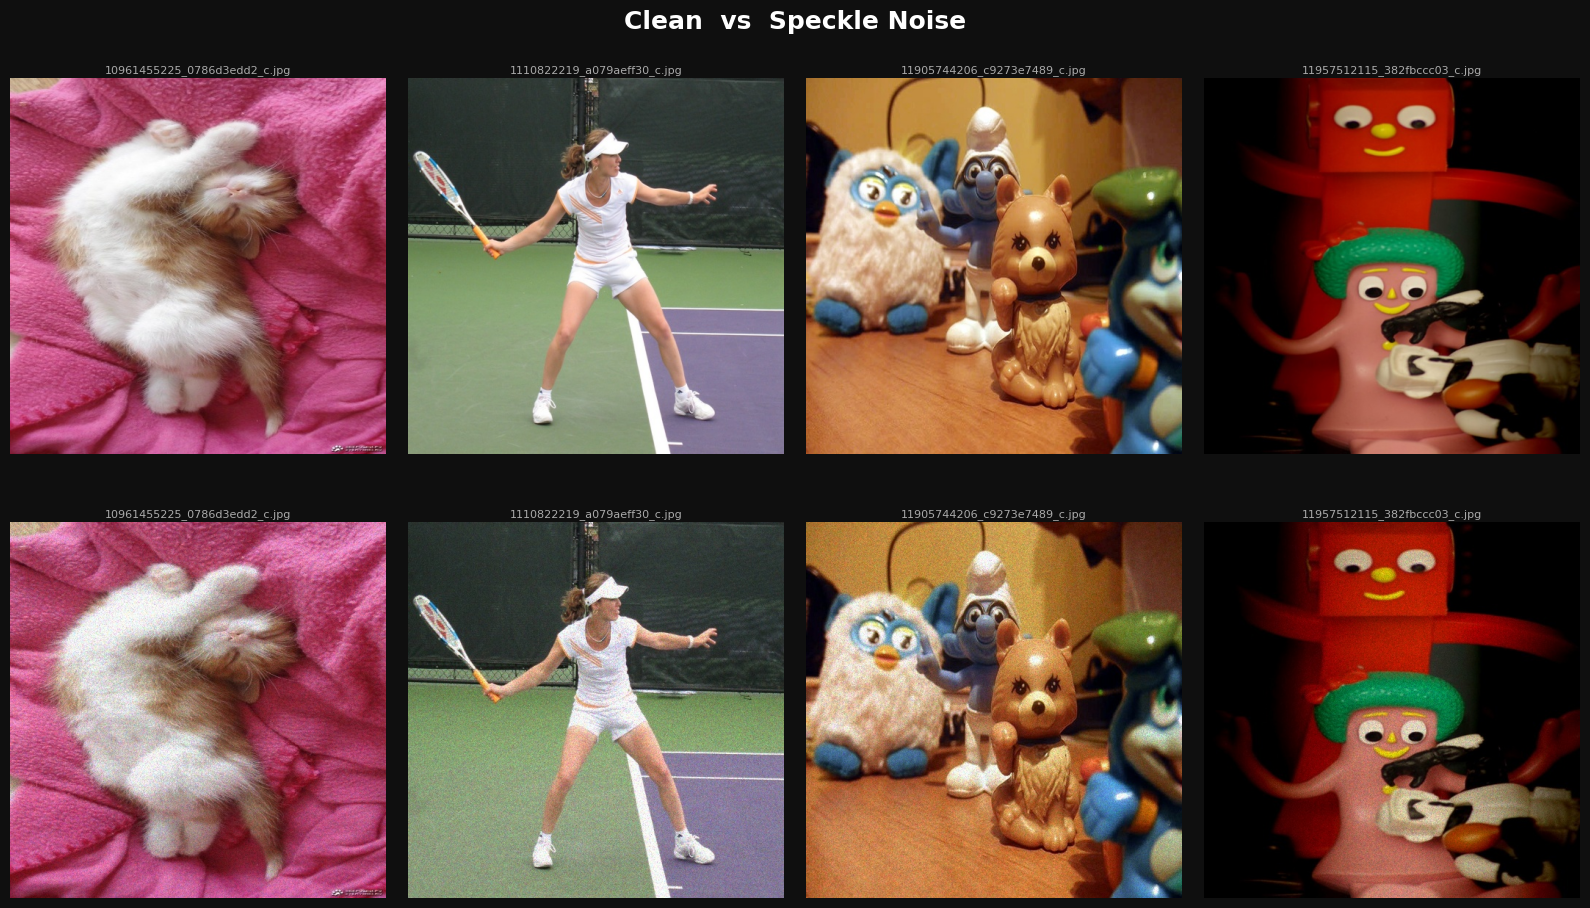

In [13]:
def visualize_clean_vs_speckle(clean_folder, speckle_folder, n=3):
    """
    Displays the first n images of the dataset: clean (top) and speckle (bottom).    
    """
    clean_folder = Path(clean_folder)
    speckle_folder = Path(speckle_folder)

    # Get images
    exts = ["*.png", "*.jpg", "*.jpeg"]
    clean_imgs = sorted([p for ext in exts for p in clean_folder.glob(ext)])[:n]
    speckle_imgs = sorted([p for ext in exts for p in speckle_folder.glob(ext)])[:n]

    n_cols = min(n, len(clean_imgs), len(speckle_imgs))

    fig, axes = plt.subplots(
        2, n_cols,
        figsize=(n_cols * 4, 9),
        facecolor="#0f0f0f"
    )
    fig.suptitle("Clean  vs  Speckle Noise", fontsize=18, fontweight="bold",
                 color="white", y=1.01)

    row_labels = ["CLEAN", "SPECKLE"]
    row_colors = ["#4ade80", "#f87171"] 

    for row, (img_list, label, color) in enumerate(
        zip([clean_imgs, speckle_imgs], row_labels, row_colors)
    ):
        for col in range(n_cols):
            ax = axes[row][col] if n_cols > 1 else axes[row]
            img = Image.open(img_list[col]).convert("RGB")
            ax.imshow(np.array(img))
            ax.axis("off")

            for spine in ax.spines.values():
                spine.set_edgecolor(color)
                spine.set_linewidth(3)
                spine.set_visible(True)

            ax.set_title(
                img_list[col].name,
                color="#aaaaaa", fontsize=8, pad=4
            )

        # Labeled
        axes[row][0].set_ylabel(
            label, fontsize=13, fontweight="bold",
            color=color, rotation=90, labelpad=10
        )

    plt.tight_layout()
    plt.subplots_adjust(hspace=0.15, wspace=0.06)
    plt.show()

# Visualize images
visualize_clean_vs_speckle(clean_output, speckle_output, n=4)

# ** Add speckle noise for the Training Dataset**

In this section, we prepare the dataset that will be used to train the **U-Net denoising model**.

The process consists of two steps:

1. **Convert all images to grayscale**
2. **Generate speckle-contaminated versions of the images**


## Speckle Noise Model

Speckle noise is commonly modeled as **multiplicative noise**, which means that the noise intensity depends on the underlying signal.

The mathematical model used in this notebook is

$I_{out}(x,y) = I(x,y) + I(x,y)N(x,y)$
where

- $I(x,y)$ : original clean image  
- $N(x,y)$ : random noise  
- $I_{out}(x,y)$ : noisy image  


The noise term follows the distribution

$$
N(x,y) \sim \mathcal{N}(0,\sigma)
$$

where

- \(\sigma\) controls the **strength of the speckle noise**

---

## Randomized Speckle Intensity

To increase the robustness of the neural network, each image is corrupted using a **different speckle intensity**.

The noise level is randomly sampled from the interval

$$
\sigma \in [0.10, 0.40]
$$

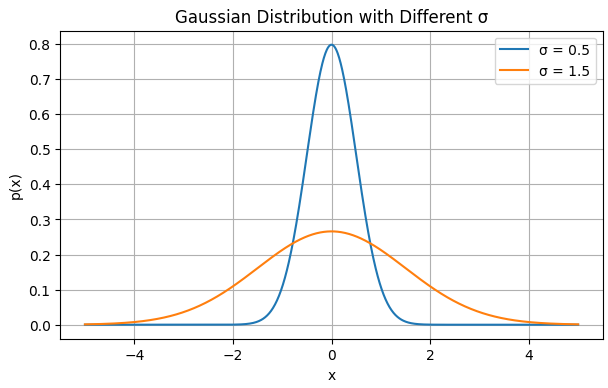

This strategy acts as a **data augmentation technique**, allowing the network to learn how to remove speckle noise under different noise conditions.



In [14]:
clean_gray_dir  = WORK_DIR / "clean_gray"
speckle_aug_dir = WORK_DIR / "speckle_augmented"

clean_gray_dir.mkdir(exist_ok=True)
speckle_aug_dir.mkdir(exist_ok=True)

def convert_to_grayscale(src_folder, dst_folder):
    """Convert all images in src_folder to grayscale and save them in dst_folder."""
    exts = ["*.png", "*.jpg", "*.jpeg"]
    images = sorted([p for ext in exts for p in Path(src_folder).glob(ext)])
    
    print(f"\n Converting {len(images)} images to grayscale...")
    for img_path in tqdm(images, desc="Grayscale"):
        img = Image.open(img_path).convert("L")          
        img.save(Path(dst_folder) / (img_path.stem + ".png"))
    
    print(f" Saved in: {dst_folder}")
    return len(images)

def add_speckle(src_folder, dst_folder, sigma_min=0.10, sigma_max=0.40):
    """
    For each image in src_folder:
      1. Convert it to grayscale
      2. Assign a random σ in [sigma_min, sigma_max]
      3. Apply multiplicative speckle noise: I_out = I + I * N(0, σ)
      4. Save it in dst_folder together with its assigned σ
    """
    exts = ["*.png", "*.jpg", "*.jpeg"]
    images = sorted([p for ext in exts for p in Path(src_folder).glob(ext)])
    
    sigma_log = {}   # store the sigma assigned to each image
    
    print(f"\n Adding speckle to {len(images)} images (σ ∈ [{sigma_min}, {sigma_max}])...")
    for img_path in tqdm(images, desc="Speckle augmentation"):
        # 1. Read image, convert to grayscale, normalize to [0, 1]
        img_gray = np.array(Image.open(img_path).convert("L"), dtype=np.float32) / 255.0
        
        # 2. Unique random sigma for each image
        sigma = round(random.uniform(sigma_min, sigma_max), 4)
        sigma_log[img_path.name] = sigma
        
        # 3. Multiplicative speckle noise
        noise = np.random.normal(0, sigma, img_gray.shape).astype(np.float32)
        img_noisy = img_gray + img_gray * noise
        
        # 4. Clamp to [0, 1] and convert back to uint8
        img_noisy = np.clip(img_noisy, 0.0, 1.0)
        img_out = Image.fromarray((img_noisy * 255).astype(np.uint8), mode="L")
        img_out.save(Path(dst_folder) / (img_path.stem + ".png"))
    
    # Save sigma log as reference
    log_path = Path(dst_folder) / "_sigma_log.txt"
    with open(log_path, "w") as f:
        f.write(f"sigma_min={sigma_min}  sigma_max={sigma_max}\n")
        f.write("-" * 40 + "\n")
        for name, s in sigma_log.items():
            f.write(f"{name}: sigma={s}\n")
    
    print(f" Saved in: {dst_folder}")
    print(f" Sigma log: {log_path}")
    return sigma_log

# gray scale and add speckle
SIGMA_MIN = 0.10
SIGMA_MAX = 0.40
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
n_clean   = convert_to_grayscale(clean_output, clean_gray_dir)
sigma_log = add_speckle(speckle_output, speckle_aug_dir, SIGMA_MIN, SIGMA_MAX)

# Summary ───────────────────────────────────────────────────────────────────
sigmas = list(sigma_log.values())
print(f"clean_gray:{n_clean:>4}, speckle_augmented:{len(sigmas):>4}, average σ:{np.mean(sigmas):.4f}")


 Converting 300 images to grayscale...


Grayscale:   0%|          | 0/300 [00:00<?, ?it/s]

 Saved in: /kaggle/working/clean_gray

 Adding speckle to 300 images (σ ∈ [0.1, 0.4])...


Speckle augmentation:   0%|          | 0/300 [00:00<?, ?it/s]

/tmp/ipykernel_55/3420872512.py:48: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img_out = Image.fromarray((img_noisy * 255).astype(np.uint8), mode="L")


 Saved in: /kaggle/working/speckle_augmented
 Sigma log: /kaggle/working/speckle_augmented/_sigma_log.txt
clean_gray: 300, speckle_augmented: 300, average σ:0.2479


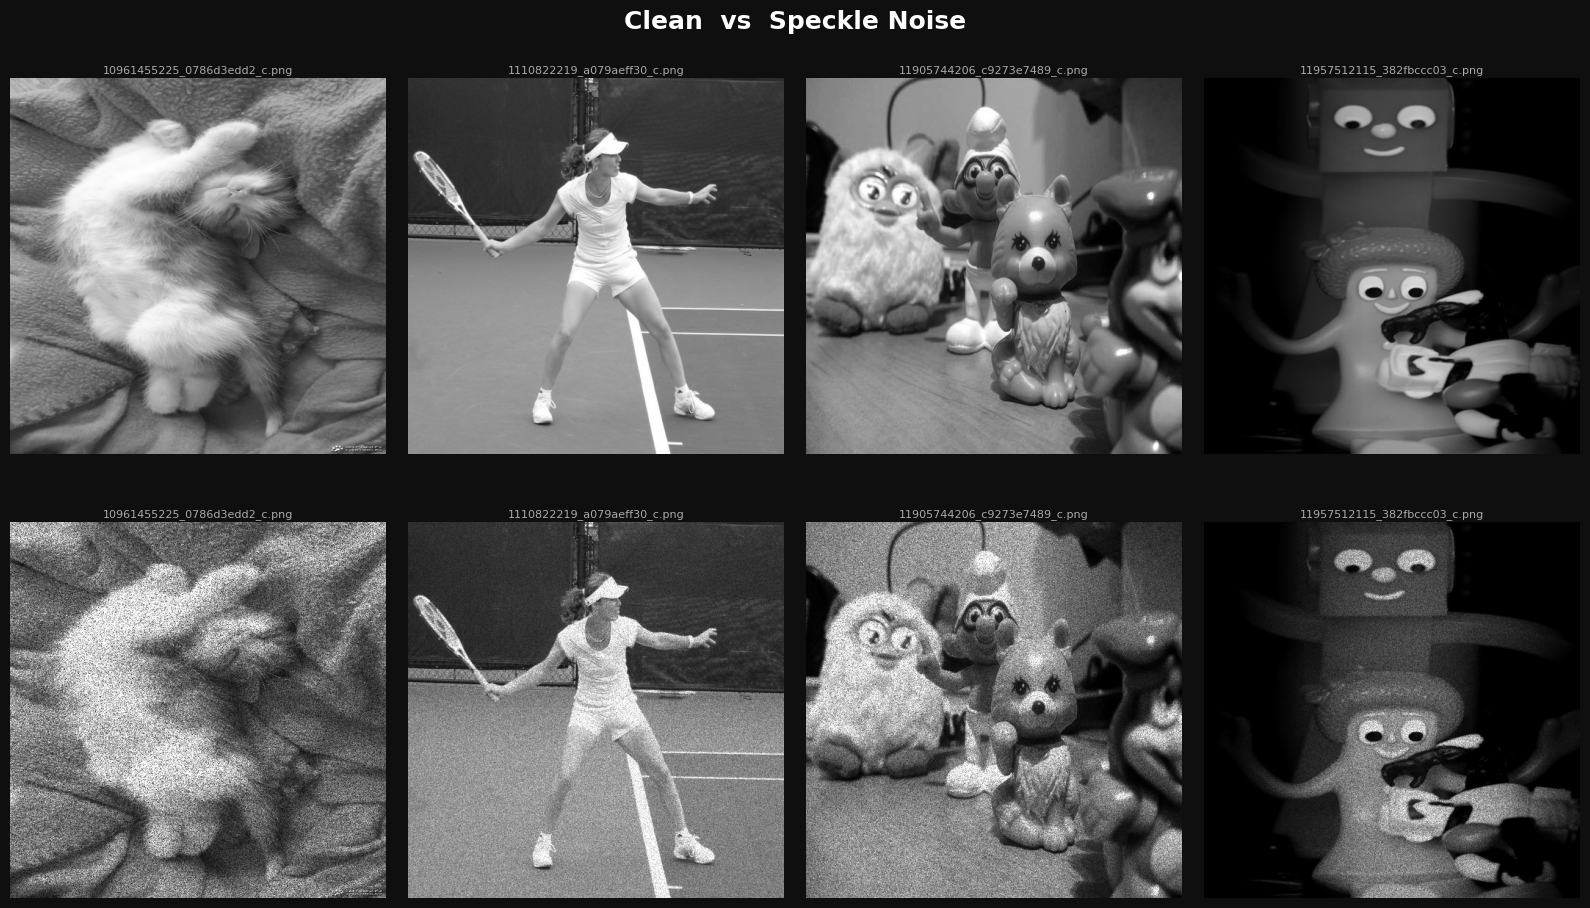

In [13]:
# Visualize images
visualize_clean_vs_speckle(clean_gray_dir, speckle_aug_dir, n=4)

## Quantitative Analysis of Speckle Noise

Visual inspection is useful, but it is not enough to fully understand the effect of speckle noise on image quality.  
For this reason, in this section we evaluate the dataset using several **quantitative image-quality metrics**.

The goal is to compare the **clean images** and their corresponding **speckle-contaminated versions**, in order to measure how noise alters the statistical and visual properties of the data.

### 1. Peak Signal-to-Noise Ratio (PSNR)

PSNR measures the level of degradation of a noisy image with respect to its clean reference. It is computed from the mean squared error (MSE) between both images:

$$
\mathrm{PSNR} = 10 \log_{10}\left(\frac{255^2}{\mathrm{MSE}}\right)
$$

where

$$
\mathrm{MSE} = \frac{1}{MN} \sum_{x=1}^{M}\sum_{y=1}^{N} \left(I_c(x,y) - I_n(x,y)\right)^2
$$

Here:

- $I_c(x,y)$ is the clean image
- $I_n(x,y)$ is the noisy image
- $M$ and $N$ are the image dimensions

A **higher PSNR** indicates that the noisy image remains closer to the clean reference.

---

### 2. Speckle Index (SI)

The Speckle Index is a simple measure of relative fluctuation in image intensity:

$$
\mathrm{SI} = \frac{\sigma}{\mu}
$$

where

- $\mu$ is the mean intensity
- $\sigma$ is the standard deviation of intensity

A **lower SI** indicates less relative fluctuation and therefore less speckle contamination.

---

### 3. Equivalent Number of Looks (ENL)

ENL is widely used in coherent imaging to estimate image smoothness in homogeneous regions:

$$
\mathrm{ENL} = \left(\frac{\mu}{\sigma}\right)^2
$$

A **higher ENL** indicates a more uniform image and, in general, lower speckle effect.

---



 Paired images found: 300


Computing metrics:   0%|          | 0/300 [00:00<?, ?it/s]

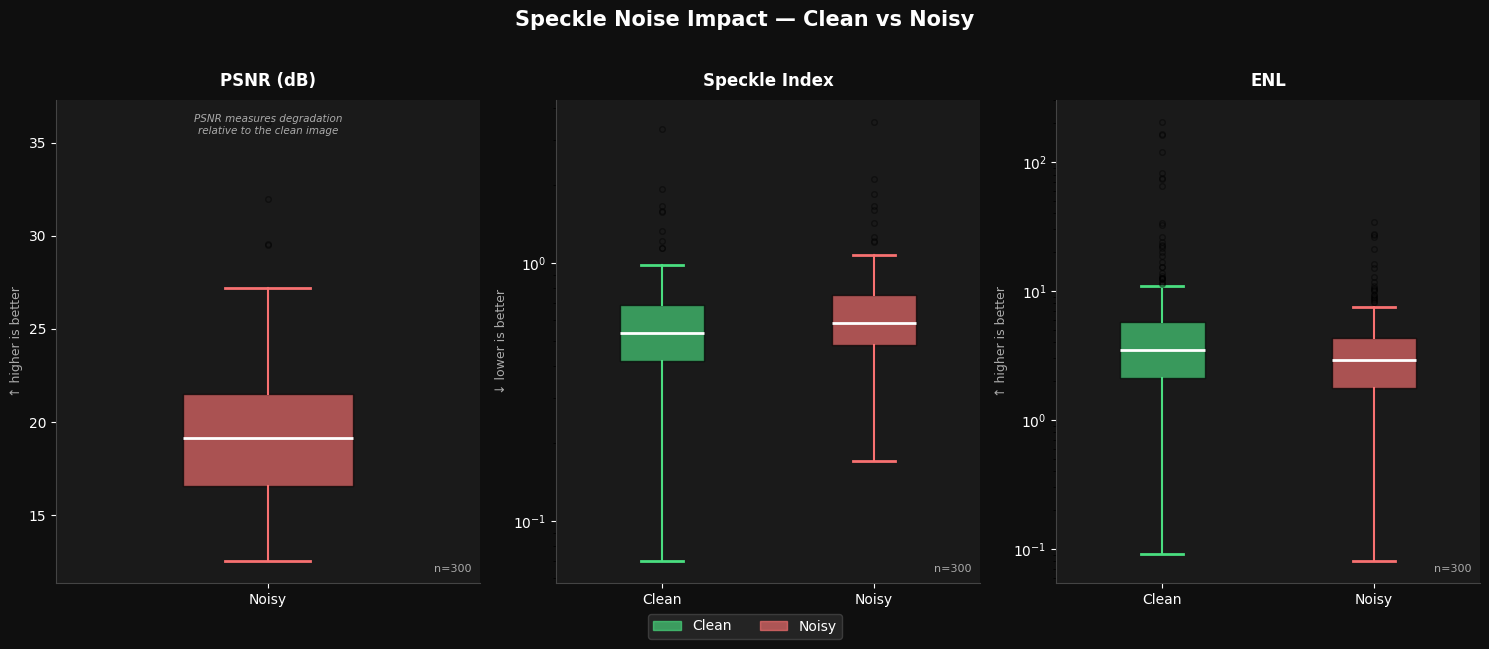

In [15]:
def analyze_and_plot(clean_folder, noisy_folder, save_path=None):
    """
    For each metric, shows TWO boxplots: clean vs noisy.
    Visualizes the impact of speckle noise on each metric.
    """
    clean_folder = Path(clean_folder)
    noisy_folder = Path(noisy_folder)

    # ── Match images by filename ──────────────────────────────────────────────
    clean_files = {f.stem: f for f in sorted(clean_folder.glob("*.png"))}
    noisy_files = {f.stem: f for f in sorted(noisy_folder.glob("*.png"))
                   if not f.name.startswith("_")}
    common = sorted(set(clean_files.keys()) & set(noisy_files.keys()))

    assert len(common) > 0, "No paired images found with the same filename in both folders."
    print(f"\n Paired images found: {len(common)}")

    # ── Compute metrics for BOTH sets ─────────────────────────────────────────
    metrics = {
        "PSNR (dB)":     {"clean": [], "noisy": [], "direction": "↑ higher is better"},
        "Speckle Index": {"clean": [], "noisy": [], "direction": "↓ lower is better"},
        "ENL":           {"clean": [], "noisy": [], "direction": "↑ higher is better"},
    }

    for stem in tqdm(common, desc="Computing metrics"):
        img_c = np.array(Image.open(clean_files[stem]).convert("L"))
        img_n = np.array(Image.open(noisy_files[stem]).convert("L"))

        if img_c.shape != img_n.shape:
            img_n = np.array(
                Image.open(noisy_files[stem]).convert("L").resize(
                    (img_c.shape[1], img_c.shape[0]), Image.BILINEAR
                )
            )

        # PSNR: requires a reference/noisy pair
        mse = np.mean((img_c.astype(np.float32) - img_n.astype(np.float32)) ** 2)
        psnr = 10 * np.log10(255.0 ** 2 / mse) if mse > 0 else float("inf")
        metrics["PSNR (dB)"]["noisy"].append(psnr)

        # SI and ENL: intrinsic per-image metrics
        for key, img in [("clean", img_c), ("noisy", img_n)]:
            mu    = np.mean(img.astype(np.float32))
            sigma = np.std(img.astype(np.float32))
            metrics["Speckle Index"][key].append(sigma / mu if mu > 0 else 0.0)
            metrics["ENL"][key].append((mu / sigma) ** 2 if sigma > 0 else 0.0)

    # ── Boxplots ──────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(15, 6), facecolor="#0f0f0f")
    fig.suptitle(
        "Speckle Noise Impact — Clean vs Noisy",
        fontsize=15, fontweight="bold", color="white", y=1.02
    )

    COLOR_CLEAN = "#4ade80"
    COLOR_NOISY = "#f87171"

    def style_box(bp, color):
        bp["boxes"][0].set_facecolor(color)
        bp["boxes"][0].set_alpha(0.65)
        bp["medians"][0].set(color="white", linewidth=2)
        for w in bp["whiskers"]: w.set(color=color, linewidth=1.5)
        for c in bp["caps"]:     c.set(color=color, linewidth=2)
        for f in bp["fliers"]:   f.set(marker="o", color=color, alpha=0.4, markersize=4)

    BOX_PROPS = dict(
        patch_artist=True,
        widths=0.4,
        medianprops=dict(color="white", linewidth=2),
        whiskerprops=dict(linewidth=1.5),
        capprops=dict(linewidth=2),
        flierprops=dict(marker="o", alpha=0.4, markersize=4, linestyle="none"),
    )

    for ax, (metric_name, data) in zip(axes, metrics.items()):
        direction = data["direction"]

        if metric_name == "PSNR (dB)":
            # PSNR only makes sense for noisy (clean vs itself = inf)
            bp_n = ax.boxplot(data["noisy"], positions=[1], **BOX_PROPS)
            style_box(bp_n, COLOR_NOISY)
            ax.set_xticks([1])
            ax.set_xticklabels(["Noisy"], color="white", fontsize=10)
            ax.text(0.5, 0.97,
                    "PSNR measures degradation\nrelative to the clean image",
                    transform=ax.transAxes, color="#aaaaaa", fontsize=7.5,
                    ha="center", va="top", style="italic")
        else:
            bp_c = ax.boxplot(data["clean"], positions=[1], **BOX_PROPS)
            bp_n = ax.boxplot(data["noisy"], positions=[2], **BOX_PROPS)
            style_box(bp_c, COLOR_CLEAN)
            style_box(bp_n, COLOR_NOISY)
            ax.set_xticks([1, 2])
            ax.set_xticklabels(["Clean", "Noisy"], color="white", fontsize=10)

        # ── General subplot style (applied to all 3) ──────────────────────────
        ax.set_facecolor("#1a1a1a")
        ax.set_title(metric_name, color="white", fontsize=12, fontweight="bold", pad=10)
        ax.set_ylabel(direction, color="#aaaaaa", fontsize=9)

        if metric_name in ("Speckle Index", "ENL"):
            ax.set_yscale("log")
            ax.yaxis.set_minor_formatter(plt.NullFormatter())

        ax.tick_params(colors="white")
        ax.spines[["top", "right"]].set_visible(False)
        for spine in ["bottom", "left"]:
            ax.spines[spine].set_color("#444444")
        ax.text(0.98, 0.02, f"n={len(common)}", transform=ax.transAxes,
                color="#aaaaaa", fontsize=8, ha="right", va="bottom")

    # ── Global legend ─────────────────────────────────────────────────────────
    legend_patches = [
        mpatches.Patch(color=COLOR_CLEAN, alpha=0.65, label="Clean"),
        mpatches.Patch(color=COLOR_NOISY, alpha=0.65, label="Noisy"),
    ]
    fig.legend(handles=legend_patches, loc="lower center", ncol=2,
               fontsize=10, facecolor="#2a2a2a", edgecolor="#444444",
               labelcolor="white", bbox_to_anchor=(0.5, -0.04))

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight", facecolor="#0f0f0f")
        print(f"\n Figure saved at: {save_path}")
    plt.show()


# ── Call ──────────────────────────────────────────────────────────────────────
analyze_and_plot(
    clean_folder = clean_gray_dir,
    noisy_folder = speckle_aug_dir,
)

## Dataset Configuration and Hyperparameters

Before training the neural network, we define a set of **global hyperparameters** that control how the dataset is prepared and loaded during training.

These parameters determine the image resolution, batch size, and how the dataset is divided between training and validation.

### Global Hyperparameters

- **Image Size (`IMG_SIZE`)**  
  All images are resized to **128 × 128 pixels**. Using a fixed resolution ensures that every sample has the same spatial dimensions, which is required for batch processing in neural networks.

- **Batch Size (`BATCH_SIZE`)**  
  The number of samples processed in each training iteration. A batch size of **32** provides a good balance between computational efficiency and GPU memory usage.

- **Train/Validation Split (`TRAIN_SPLIT`)**  
  The dataset is divided into **85% training data** and **15% validation data**.  
  The training set is used to update the model parameters, while the validation set is used to monitor the model’s generalization performance.

- **Number of Workers (`NUM_WORKERS`)**  
  Defines how many parallel processes are used for loading the data. Increasing this value can speed up training by preparing batches while the model is computing.

---

## Paired Dataset for Image Denoising

The speckle removal problem is formulated as a **supervised image-to-image learning task**.

Each sample in the dataset consists of a **pair of images**:

- **Input:** a speckle-contaminated image  
- **Target:** the corresponding clean image

The neural network learns a mapping of the form

\[
\text{Noisy Image} \rightarrow \text{Clean Image}
\]

Since the images are grayscale, each sample is represented as a tensor with shape

\[
[1, 128, 128]
\]

where:

- `1` is the number of channels  
- `128 × 128` is the spatial resolution

---

## Data Preprocessing

Each image undergoes a simple preprocessing pipeline:

1. **Resize** the image to a fixed resolution  
2. **Convert to tensor**, transforming pixel values from `[0,255]` to `[0,1]`

This ensures the data is in a format suitable for training deep neural networks.

---

## Data Augmentation

An optional **horizontal flip augmentation** is included to increase dataset variability.

A key detail is that the **same random transformation must be applied to both the noisy and clean images**.  
This guarantees that the input and target remain perfectly aligned.

To achieve this, the same random seed is used when applying transformations to both images in each sample.


In [16]:
# ── Global Hyperparameters ──────────────────────────────────────────────

IMG_SIZE    = 128     # Images are resized to 128×128 pixels
BATCH_SIZE  = 32      # Number of samples processed per iteration
TRAIN_SPLIT = 0.85    # 85% training, 15% validation
NUM_WORKERS = 2       # Parallel workers for faster data loading

print("Configuration:")
print(f"   Image size (resized): {IMG_SIZE}×{IMG_SIZE}")
print(f"   Batch size:           {BATCH_SIZE}")
print(f"   Train/Val split:      {int(TRAIN_SPLIT*100)}/{int((1-TRAIN_SPLIT)*100)}")

class SpeckleDataset(Dataset):
    """
    Dataset that loads pairs of images (noisy, clean).
    
    Each sample is a tuple:  
    - input: Speckle image (what enters the Autoencoder)
    - target: clean image (what we want to predict)
    """

    def __init__(self, clean_files, noisy_files, img_size=128, augment=False):
        assert len(clean_files) == len(noisy_files)
        self.clean_files = clean_files
        self.noisy_files = noisy_files
        self.augment     = augment

        # Basic transformations: resize + tensor + normalization
        self.base_transform = transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor(),           # [0, 255] → [0.0, 1.0]
        ])

    def __len__(self):
        return len(self.clean_files)

    def __getitem__(self, idx):
        # THIS IS VERIY IMPORTANT
        seed = idx + SEED

        noisy = Image.open(self.noisy_files[idx]).convert('L')
        clean = Image.open(self.clean_files[idx]).convert('L')

        # augmentation
        if self.augment:
            torch.manual_seed(seed)
            flip = transforms.RandomHorizontalFlip(p=0.5)
            noisy = flip(noisy)
            torch.manual_seed(seed)
            clean = flip(clean)

        noisy_t = self.base_transform(noisy)
        clean_t = self.base_transform(clean)

        return noisy_t, clean_t

print(f"   Input: noisy image (Speckle) — shape: [1, {IMG_SIZE}, {IMG_SIZE}]")
print(f"   target: denoisy image        — shape: [1, {IMG_SIZE}, {IMG_SIZE}]")

Configuration:
   Image size (resized): 128×128
   Batch size:           32
   Train/Val split:      85/15
   Input: noisy image (Speckle) — shape: [1, 128, 128]
   target: denoisy image        — shape: [1, 128, 128]


## Creating the Training and Validation Sets


Once the paired dataset has been defined, the next step is to divide it into **training** and **validation** subsets.

This separation is essential in supervised learning:

- the **training set** is used to optimize the model parameters
- the **validation set** is used to evaluate how well the model generalizes to unseen data during training

In this notebook, the dataset is split according to the predefined ratio:

$$
85\% \text{ for training}, \qquad 15\% \text{ for validation}
$$

To ensure that the split is **reproducible**, a fixed random seed is used.  
This guarantees that the same images are assigned to the training and validation sets every time the notebook is executed.

---

## Data Augmentation in the Training Set

After splitting the dataset, data augmentation can be enabled or disabled for the training subset.

In this case, augmentation is currently set to:

- **disabled** for training
- naturally **disabled** for validation

This means that the model will learn directly from the original noisy-clean image pairs without additional transformations.

---

## Device Selection

The code automatically checks whether a **GPU (CUDA)** is available.

If a GPU is detected, the training process can be significantly accelerated.  
Otherwise, the model will run on the CPU.

This step is important because deep learning training is computationally intensive, especially when processing image batches over many epochs.




In [18]:
# ── Create complete dataset and split into train/val ─────────────────────────────
clean_files = sorted(clean_gray_dir.glob("*.png"))
noisy_files = sorted(speckle_aug_dir.glob("*.png"))

full_dataset = SpeckleDataset(clean_files, noisy_files, img_size=IMG_SIZE, augment=False)

n_total = len(full_dataset)
n_train = int(n_total * TRAIN_SPLIT)
n_val   = n_total - n_train

train_dataset, val_dataset = random_split(
    full_dataset, [n_train, n_val],
    generator=torch.Generator().manual_seed(SEED)
)

# Activate or desactivate data augmentation
train_dataset.dataset.augment = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=(device=='cuda'))
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=(device=='cuda'))

print(f"\nDataset split:")
print(f"   Total:        {n_total:>5} pairs")
print(f"   Training:     {n_train:>5} pairs ({int(TRAIN_SPLIT*100)}%)")
print(f"   Validation:   {n_val:>5} pairs ({int((1-TRAIN_SPLIT)*100)}%)")

print(f"\nBatches per epoch:")
print(f"   Train: {len(train_loader)} batches × {BATCH_SIZE} images")
print(f"   Val:   {len(val_loader)} batches × {BATCH_SIZE} images")

Using device: cpu

Dataset split:
   Total:          300 pairs
   Training:       255 pairs (85%)
   Validation:      45 pairs (15%)

Batches per epoch:
   Train: 8 batches × 32 images
   Val:   2 batches × 32 images


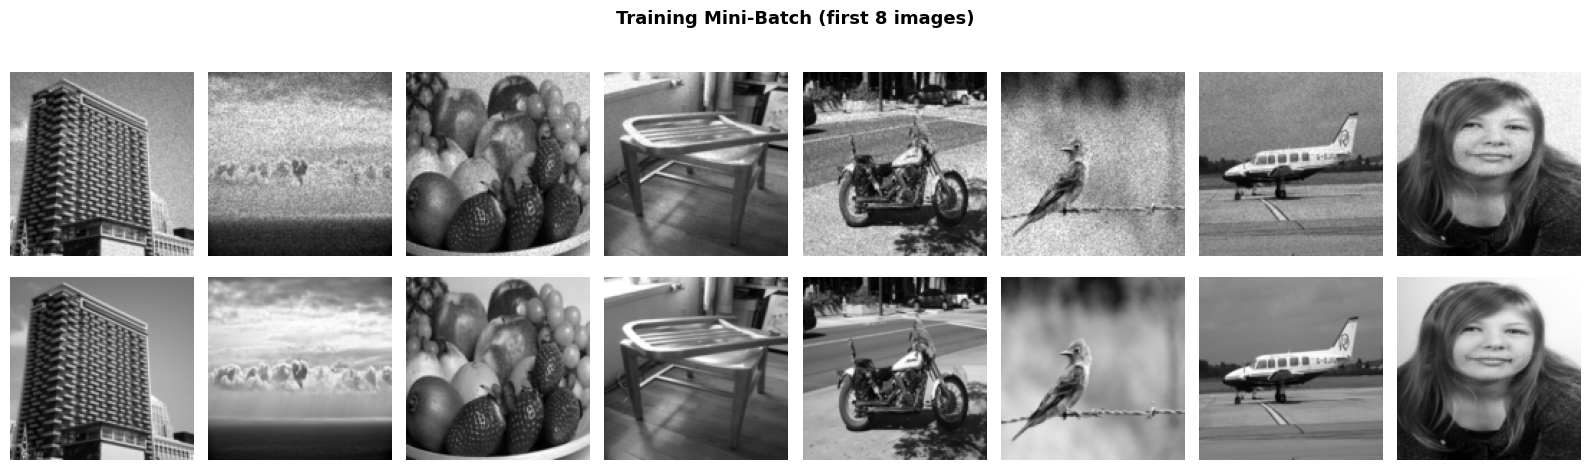

In [23]:
# Visualize a mini-batch
noisy_batch, clean_batch = next(iter(train_loader))
fig, axes = plt.subplots(2, 8, figsize=(16, 5))
fig.suptitle(f'Training Mini-Batch (first 8 images)', fontsize=13, fontweight='bold')

for i in range(8):
    axes[0, i].imshow(noisy_batch[i, 0].numpy(), cmap='gray')
    axes[0, i].axis('off')
    axes[1, i].imshow(clean_batch[i, 0].numpy(), cmap='gray')
    axes[1, i].axis('off')

axes[0, 0].set_ylabel('Noisy (entrance)', fontsize=10)
axes[1, 0].set_ylabel('Clean\n(target)', fontsize=10)
plt.tight_layout()
plt.show()

# Convolutional Autoencoder Architecture

We will use a Convolutional Autoencoder (ConvAE) with a U-Net Lite architecture:
- The Encoder uses convolutions and MaxPooling to compress the image.

- The Decoder uses convolutions and Upsampling to reconstruct the clean image.

- Skip connections between the encoder and decoder preserve fine details.

  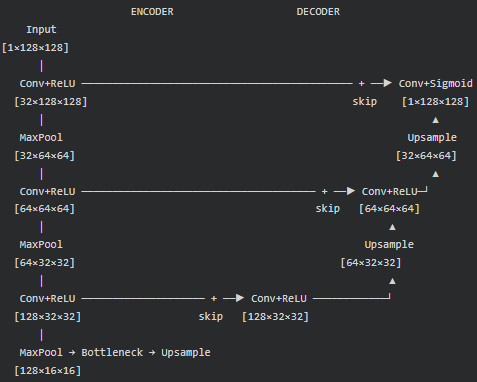

In [24]:
class ConvBlock(nn.Module):
    """Convolutionla block: Conv → BatchNorm → ReLU (×2)"""

    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)

In [29]:
class SpeckleDenoiseUnet(nn.Module):
    """
    Convolutional autoencoder with skip connections for speckle noise removal.

    Architecture:
        - Encoder: four downsampling stages based on ConvBlocks
        - Bottleneck: deepest compressed representation
        - Decoder: four upsampling stages with skip connections from the encoder
        - Output layer: maps features to a single restored grayscale image
    """

    def __init__(self, in_channels=1, features=[32, 64, 128, 256]):
        super().__init__()

        # ── Encoder ──────────────────────────────────────────────────────────
        self.enc1 = ConvBlock(in_channels, features[0])   # 128 → 128
        self.enc2 = ConvBlock(features[0], features[1])   # 64  → 64
        self.enc3 = ConvBlock(features[1], features[2])   # 32  → 32
        self.enc4 = ConvBlock(features[2], features[3])   # 16  → 16

        self.pool = nn.MaxPool2d(2, 2)

        # ── Bottleneck ───────────────────────────────────────────────────────
        self.bottleneck = ConvBlock(features[3], features[3] * 2)  # 8×8

        # ── Decoder ──────────────────────────────────────────────────────────
        self.up4 = nn.ConvTranspose2d(features[3]*2, features[3], kernel_size=2, stride=2)
        self.dec4 = ConvBlock(features[3]*2, features[3])   # +skip

        self.up3 = nn.ConvTranspose2d(features[3], features[2], kernel_size=2, stride=2)
        self.dec3 = ConvBlock(features[2]*2, features[2])   # +skip

        self.up2 = nn.ConvTranspose2d(features[2], features[1], kernel_size=2, stride=2)
        self.dec2 = ConvBlock(features[1]*2, features[1])   # +skip

        self.up1 = nn.ConvTranspose2d(features[1], features[0], kernel_size=2, stride=2)
        self.dec1 = ConvBlock(features[0]*2, features[0])   # +skip

        # ── Ouput Layer ───────────────────────────────────────────────────
        self.output_conv = nn.Sequential(
            nn.Conv2d(features[0], in_channels, kernel_size=1),
            nn.Sigmoid()   # values between [0, 1]
        )

    def forward(self, x):
        # Encoder with skip connections
        s1 = self.enc1(x)              # skip 1
        s2 = self.enc2(self.pool(s1))  # skip 2
        s3 = self.enc3(self.pool(s2))  # skip 3
        s4 = self.enc4(self.pool(s3))  # skip 4

        # Bottleneck
        z = self.bottleneck(self.pool(s4))

        # Decoder with concatened skips
        d4 = self.dec4(torch.cat([self.up4(z),  s4], dim=1))
        d3 = self.dec3(torch.cat([self.up3(d4), s3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), s2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), s1], dim=1))

        return self.output_conv(d1)

# Create the model
model = SpeckleDenoiseUnet(in_channels=1, features=[32, 64, 128, 256]).to(device)

# Model summary
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"   Trainable parameters: {total_params:,}")


   Trainable parameters: 7,765,409


In [30]:
# ── Forward pass test ─────────────────────────────────────────────────────
# This block verifies that the model can process an input tensor and produce

with torch.no_grad():
    # Create a random test input with the same shape as a real image
    test_input = torch.randn(1, 1, IMG_SIZE, IMG_SIZE).to(device)

    # Run a forward pass through the network
    test_output = model(test_input)

print("Forward pass successful:")
print(f"   Input shape:  {list(test_input.shape)}")
print(f"   Output shape: {list(test_output.shape)}")

# Check output value range (expected to be in [0,1] due to Sigmoid)
print(f"   Output range: [{test_output.min():.3f}, {test_output.max():.3f}]")

# Ensure input and output shapes match
assert test_input.shape == test_output.shape, \
    "Input and output shapes do not match!"

print("\nShapes are consistent between input and output.")

Forward pass successful:
   Input shape:  [1, 1, 128, 128]
   Output shape: [1, 1, 128, 128]
   Output range: [0.276, 0.880]

Shapes are consistent between input and output.


## Loss Function and Optimizer

To remove speckle noise, we use a combined loss function that considers both pixel errors and perceptual structure:

$$\mathcal{L}_{\text{total}} = \alpha \cdot \mathcal{L}_{\text{MSE}} + \beta \cdot \mathcal{L}_{\text{SSIM}}$$

- **MSE** ($\mathcal{L}_{\text{MSE}}$): penalizes pixel-by-pixel errors.

- **SSIM** ($\mathcal{L}_{\text{SSIM}}$): measures structural similarity (more perceptually significant).

- **Adam optimizer** with learning rate decay (ReduceLROnPlateau).

In [33]:
# ── Training hyperparameters ───────────────────────────────────────────────
LEARNING_RATE  = 1e-3
NUM_EPOCHS     = 40
PATIENCE       = 10    # early stopping patience
ALPHA_MSE      = 0.8   # weight of MSE in the combined loss
ALPHA_SSIM     = 0.2   # weight of SSIM

# ── MSE loss ───────────────────────────────────────────────────────────────
mse_loss = nn.MSELoss()

# ── SSIM loss (simplified implementation) ──────────────────────────────────
def ssim_loss(pred, target, window_size=11):
    """
    Simplified SSIM loss.
    SSIM ∈ [-1, 1], therefore SSIM Loss = 1 - SSIM ∈ [0, 2].
    Values closer to 0 indicate higher structural similarity.
    """
    C1 = 0.01 ** 2
    C2 = 0.03 ** 2

    mu_x = F.avg_pool2d(pred,   window_size, 1, window_size//2)
    mu_y = F.avg_pool2d(target, window_size, 1, window_size//2)

    sigma_x  = F.avg_pool2d(pred**2,    window_size, 1, window_size//2) - mu_x**2
    sigma_y  = F.avg_pool2d(target**2,  window_size, 1, window_size//2) - mu_y**2
    sigma_xy = F.avg_pool2d(pred*target, window_size, 1, window_size//2) - mu_x*mu_y

    ssim_map = ((2*mu_x*mu_y + C1) * (2*sigma_xy + C2)) / \
               ((mu_x**2 + mu_y**2 + C1) * (sigma_x + sigma_y + C2))
    return 1 - ssim_map.mean()


def combined_loss(pred, target):
    """Combined loss: MSE + SSIM."""
    return ALPHA_MSE * mse_loss(pred, target) + ALPHA_SSIM * ssim_loss(pred, target)


# ── Optimizer and learning rate scheduler ──────────────────────────────────
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5
)

print("✅ Training configuration:")
print(f"   Optimizer:   Adam (lr={LEARNING_RATE})")
print(f"   Scheduler:   ReduceLROnPlateau (factor=0.5, patience=5)")
print(f"   Loss:        {ALPHA_MSE}×MSE + {ALPHA_SSIM}×SSIM")
print(f"   Early stop:  patience={PATIENCE} epochs")
print(f"   Total epochs:{NUM_EPOCHS}")

✅ Training configuration:
   Optimizer:   Adam (lr=0.001)
   Scheduler:   ReduceLROnPlateau (factor=0.5, patience=5)
   Loss:        0.8×MSE + 0.2×SSIM
   Early stop:  patience=10 epochs
   Total epochs:40


# Training

We trained the model for NUM_EPOCHS epochs. In each epoch:

We forward-propagated the pairs (noisy, clean).
We calculated the combined loss.
We back-propagated and updated the weights.
We monitored the metrics during validation.

In [34]:
def compute_psnr(pred, target):
    """Peak Signal-to-Noise Ratio in dB."""
    mse = F.mse_loss(pred, target)
    if mse == 0:
        return float('inf')
    return 10 * torch.log10(torch.tensor(1.0) / mse).item()


def train_one_epoch(model, loader, optimizer, loss_fn, device):
    """Train the model a whole epcoh."""
    model.train()
    total_loss, total_psnr = 0.0, 0.0

    for noisy, clean in loader:
        noisy, clean = noisy.to(device), clean.to(device)

        pred = model(noisy)
        loss = loss_fn(pred, clean)

        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item()
        total_psnr += compute_psnr(pred.detach(), clean)

    return total_loss / len(loader), total_psnr / len(loader)

@torch.no_grad()
def evaluate(model, loader, loss_fn, device):
    """Evaluate the model on the validation set."""
    model.eval()
    total_loss, total_psnr = 0.0, 0.0

    for noisy, clean in loader:
        noisy, clean = noisy.to(device), clean.to(device)
        pred = model(noisy)
        loss = loss_fn(pred, clean)
        total_loss += loss.item()
        total_psnr += compute_psnr(pred, clean)

    return total_loss / len(loader), total_psnr / len(loader)


In [35]:
# ── Main Training Loop ──────────────────────────────────────────
history = {'train_loss': [], 'val_loss': [], 'train_psnr': [], 'val_psnr': []}

best_val_loss  = float('inf')
patience_count = 0
best_model_path = '/kaggle/working/best_speckle_ae.pth'

print(f" Starting training — {NUM_EPOCHS} epochs")
print(f"   Saving the best model in: {best_model_path}")
print("-" * 70)

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_psnr = train_one_epoch(model, train_loader, optimizer, combined_loss, device)
    val_loss,   val_psnr   = evaluate(model, val_loader, combined_loss, device)

    scheduler.step(val_loss)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_psnr'].append(train_psnr)
    history['val_psnr'].append(val_psnr)

    # Saving the best model in
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_count = 0
        torch.save(model.state_dict(), best_model_path)
        saved = 'Saved'
    else:
        patience_count += 1
        saved = ''

    # Log each 5 epcohs
    if epoch % 5 == 0 or epoch == 1:
        print(f"Epcoh [{epoch:3d}/{NUM_EPOCHS}] "
              f"Train: loss={train_loss:.4f} PSNR={train_psnr:.2f}dB | "
              f"Val: loss={val_loss:.4f} PSNR={val_psnr:.2f}dB {saved}")

    # Early stopping
    if patience_count >= PATIENCE:
        print(f"\n  Early stopping in epoch {epoch} .")
        break

print("-" * 70)
print(f"\n Training completed")
print(f"   best val_loss: {best_val_loss:.4f}")

 Starting training — 40 epochs
   Saving the best model in: /kaggle/working/best_speckle_ae.pth
----------------------------------------------------------------------
Epcoh [  1/40] Train: loss=0.0799 PSNR=17.39dB | Val: loss=0.1636 PSNR=12.39dB Saved
Epcoh [  5/40] Train: loss=0.0169 PSNR=27.13dB | Val: loss=0.0596 PSNR=18.61dB Saved
Epcoh [ 10/40] Train: loss=0.0114 PSNR=30.05dB | Val: loss=0.0097 PSNR=29.98dB 
Epcoh [ 15/40] Train: loss=0.0108 PSNR=30.25dB | Val: loss=0.0071 PSNR=31.16dB Saved
Epcoh [ 20/40] Train: loss=0.0093 PSNR=31.12dB | Val: loss=0.0095 PSNR=31.71dB 
Epcoh [ 25/40] Train: loss=0.0091 PSNR=30.93dB | Val: loss=0.0077 PSNR=31.50dB 
Epcoh [ 30/40] Train: loss=0.0077 PSNR=31.67dB | Val: loss=0.0085 PSNR=31.61dB 
Epcoh [ 35/40] Train: loss=0.0092 PSNR=30.42dB | Val: loss=0.0080 PSNR=29.79dB 
Epcoh [ 40/40] Train: loss=0.0078 PSNR=31.27dB | Val: loss=0.0064 PSNR=32.75dB 
----------------------------------------------------------------------

 Training completed
   bes

## Learning Curve Analysis

Learning curves allow us to diagnose training performance:
- **Decreasing loss** in both sets → successful learning.

- **Gap between train and val** → indicates overfitting if it is very large.

- **Increasing PSNR** → the model is improving reconstruction quality.

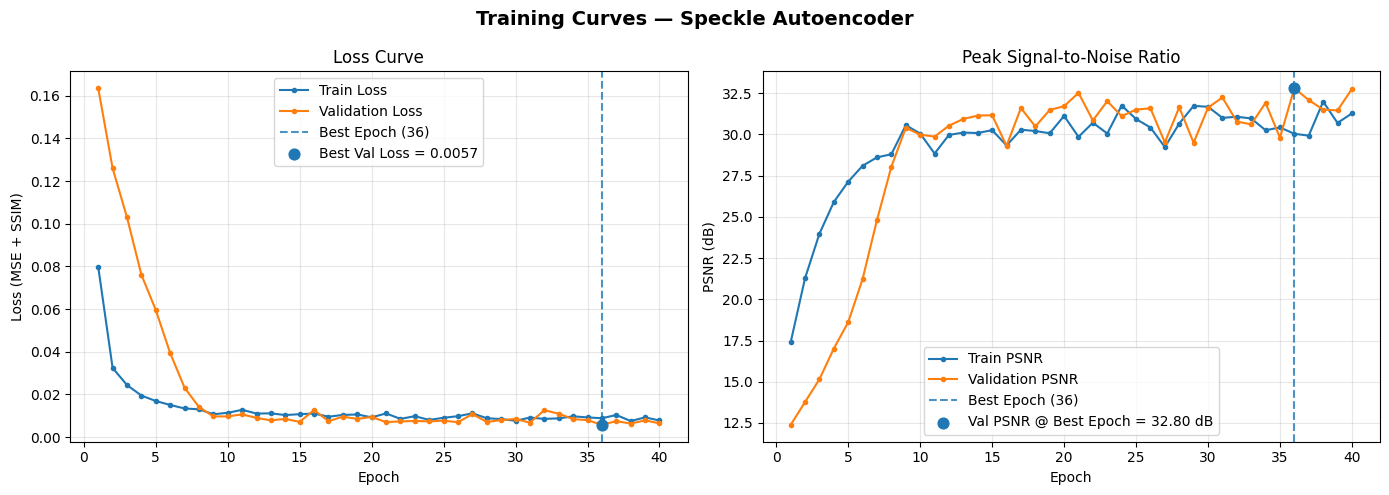


Final summary:
  Epochs trained:     40
  Best epoch:         36
  Best val loss:      0.0057
  Best val PSNR:      32.80 dB
  Initial val PSNR:   12.39 dB
  PSNR improvement:   20.41 dB


In [36]:
def plot_training_curves(history):
    """Plot training, validation, and learning-rate curves."""
    epochs = np.arange(1, len(history['train_loss']) + 1)

    best_ep = np.argmin(history['val_loss']) + 1
    best_val_loss = np.min(history['val_loss'])
    best_val_psnr = np.max(history['val_psnr'])

    has_lr = 'lr' in history

    ncols = 3 if has_lr else 2
    fig, axes = plt.subplots(1, ncols, figsize=(18 if has_lr else 14, 5))
    fig.suptitle("Training Curves — Speckle Autoencoder", fontsize=14, fontweight="bold")

    # Loss
    axes[0].plot(epochs, history['train_loss'], marker='o', markersize=3, label='Train Loss')
    axes[0].plot(epochs, history['val_loss'], marker='o', markersize=3, label='Validation Loss')
    axes[0].axvline(best_ep, linestyle='--', alpha=0.8, label=f'Best Epoch ({best_ep})')
    axes[0].scatter(best_ep, best_val_loss, s=60, zorder=5, label=f'Best Val Loss = {best_val_loss:.4f}')
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss (MSE + SSIM)")
    axes[0].set_title("Loss Curve")
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()

    # PSNR
    axes[1].plot(epochs, history['train_psnr'], marker='o', markersize=3, label='Train PSNR')
    axes[1].plot(epochs, history['val_psnr'], marker='o', markersize=3, label='Validation PSNR')
    axes[1].axvline(best_ep, linestyle='--', alpha=0.8, label=f'Best Epoch ({best_ep})')
    axes[1].scatter(best_ep, history['val_psnr'][best_ep - 1], s=60, zorder=5,
                    label=f'Val PSNR @ Best Epoch = {history["val_psnr"][best_ep - 1]:.2f} dB')
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("PSNR (dB)")
    axes[1].set_title("Peak Signal-to-Noise Ratio")
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()

    # Learning rate
    if has_lr:
        axes[2].plot(epochs, history['lr'], marker='o', markersize=3, label='Learning Rate')
        axes[2].set_xlabel("Epoch")
        axes[2].set_ylabel("Learning Rate")
        axes[2].set_title("Learning Rate Schedule")
        axes[2].grid(True, alpha=0.3)
        axes[2].legend()

    plt.tight_layout()
    plt.show()

    print("\nFinal summary:")
    print(f"  Epochs trained:     {len(epochs)}")
    print(f"  Best epoch:         {best_ep}")
    print(f"  Best val loss:      {best_val_loss:.4f}")
    print(f"  Best val PSNR:      {best_val_psnr:.2f} dB")
    print(f"  Initial val PSNR:   {history['val_psnr'][0]:.2f} dB")
    print(f"  PSNR improvement:   {best_val_psnr - history['val_psnr'][0]:.2f} dB")

plot_training_curves(history)

## Visual Evaluation of Results

Load the best model and visualize the results in validation images. We compare:
- **Original image** (clean, ground truth)
- **Image with speckle noise** (model input)
- **Denoised image** (model output)

In [106]:
# ── Load the best model ────────────────────────────────────────────────────
model.load_state_dict(torch.load(best_model_path, map_location=device))
model.eval()
print(f" Load the best model: {best_model_path}")

 Load the best model: /kaggle/working/best_speckle_ae.pth


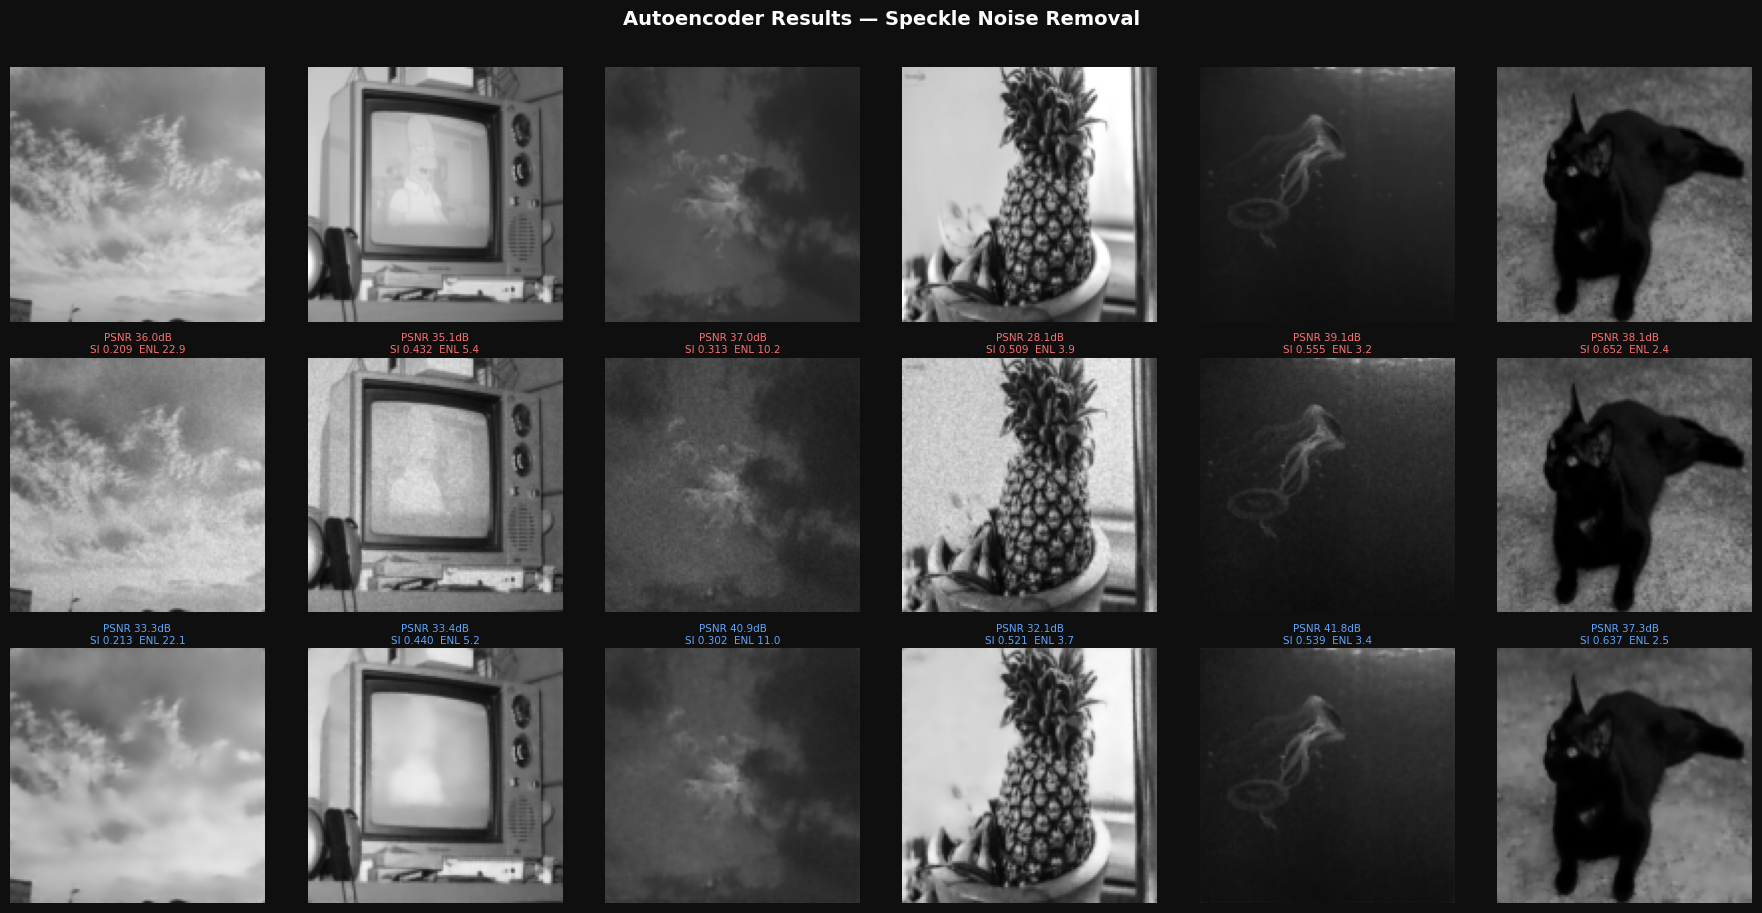


════════════════════════════════════════════════════
  Metric              Noisy    Denoised         Δ
════════════════════════════════════════════════════
  PSNR (dB) ↑           nan         nan      +nan
  Speckle Idx ↓      0.4451      0.4418   -0.0033
  ENL ↑                7.99        7.98     -0.01
════════════════════════════════════════════════════
  Samples: 6  |  Figure saved: denoising_results.png


/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [108]:
@torch.no_grad()
def visualize_results(model, loader, device, n_samples=6):
    """
    Visualizes denoising results: Clean | Noisy | Denoised.
    Reports PSNR, Speckle Index, and ENL for fair quantitative comparison.
    """
    noisy_batch, clean_batch = next(iter(loader))
    noisy_batch = noisy_batch[:n_samples].to(device)
    clean_batch = clean_batch[:n_samples]

    denoised_batch = model(noisy_batch).cpu()
    noisy_batch    = noisy_batch.cpu()

    # ── Visual grid ──────────────────────────────────────────────────────────
    fig, axes = plt.subplots(3, n_samples, figsize=(n_samples * 3, 9),
                             facecolor="#0f0f0f")
    fig.suptitle("Autoencoder Results — Speckle Noise Removal",
                 fontsize=14, fontweight="bold", color="white", y=1.01)

    row_labels  = ["Clean\n(Ground Truth)", "Noisy\n(Model Input)", "Denoised\n(Model Output)"]
    row_colors  = ["#4ade80", "#f87171", "#60a5fa"]   # verde, rojo, azul

    # ── Per-image metrics ─────────────────────────────────────────────────────
    metrics_noisy    = {"psnr": [], "si": [], "enl": []}
    metrics_denoised = {"psnr": [], "si": [], "enl": []}

    for col in range(n_samples):
        clean    = clean_batch[col, 0].numpy()        # [0,1] float
        noisy    = noisy_batch[col, 0].numpy()
        denoised = denoised_batch[col, 0].numpy()

        # Convert to [0,255] float32 for SI / ENL
        c8 = (clean    * 255).astype(np.float32)
        n8 = (noisy    * 255).astype(np.float32)
        d8 = (denoised * 255).astype(np.float32)

        # PSNR 
        def _psnr_np(ref, deg, max_val=255.0):
            mse = np.mean((ref - deg) ** 2)
            return 10 * np.log10(max_val ** 2 / mse) if mse > 0 else float("inf")

        psnr_n = _psnr_np(c8, n8)
        psnr_d = _psnr_np(c8, d8)

        # Speckle Index
        metrics_noisy["si"].append(compute_speckle_index(n8))
        metrics_denoised["si"].append(compute_speckle_index(d8))

        # ENL
        metrics_noisy["enl"].append(compute_enl(n8))
        metrics_denoised["enl"].append(compute_enl(d8))

        # ── Draw images ───────────────────────────────────────────────────────
        for row, (img, color) in enumerate(zip([clean, noisy, denoised], row_colors)):
            ax = axes[row, col]
            ax.imshow(img, cmap="gray", vmin=0, vmax=1)
            ax.axis("off")
            ax.set_facecolor("#0f0f0f")

            # Colored border per row
            for spine in ax.spines.values():
                spine.set_edgecolor(color)
                spine.set_linewidth(2)
                spine.set_visible(True)

        # Per-column metric annotations (noisy row and denoised row)
        axes[1, col].set_title(
            f"PSNR {psnr_n:.1f}dB\nSI {metrics_noisy['si'][-1]:.3f}  ENL {metrics_noisy['enl'][-1]:.1f}",
            fontsize=7.5, color="#f87171", pad=4
        )
        axes[2, col].set_title(
            f"PSNR {psnr_d:.1f}dB\nSI {metrics_denoised['si'][-1]:.3f}  ENL {metrics_denoised['enl'][-1]:.1f}",
            fontsize=7.5, color="#60a5fa", pad=4
        )

    # Row labels on leftmost column
    for row, (label, color) in enumerate(zip(row_labels, row_colors)):
        axes[row, 0].set_ylabel(label, fontsize=9, color=color,
                                fontweight="bold", labelpad=8)

    fig.patch.set_facecolor("#0f0f0f")
    plt.tight_layout()
    plt.savefig(WORK_DIR / "denoising_results.png", dpi=150,
                bbox_inches="tight", facecolor="#0f0f0f")
    plt.show()

    # ── Quantitative summary ──────────────────────────────────────────────────
    print("\n" + "═" * 52)
    print(f"  {'Metric':<14} {'Noisy':>10}  {'Denoised':>10}  {'Δ':>8}")
    print("═" * 52)

    psnr_n  = np.mean(metrics_noisy["psnr"])
    psnr_d  = np.mean(metrics_denoised["psnr"])
    si_n    = np.mean(metrics_noisy["si"])
    si_d    = np.mean(metrics_denoised["si"])
    enl_n   = np.mean(metrics_noisy["enl"])
    enl_d   = np.mean(metrics_denoised["enl"])

    print(f"  {'PSNR (dB) ↑':<14} {psnr_n:>10.2f}  {psnr_d:>10.2f}  {psnr_d - psnr_n:>+8.2f}")
    print(f"  {'Speckle Idx ↓':<14} {si_n:>10.4f}  {si_d:>10.4f}  {si_d - si_n:>+8.4f}")
    print(f"  {'ENL ↑':<14} {enl_n:>10.2f}  {enl_d:>10.2f}  {enl_d - enl_n:>+8.2f}")
    print("═" * 52)


# ── Call ──────────────────────────────────────────────────────────────────────
visualize_results(model, val_loader, device)

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128506 (\N{WORLD MAP}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


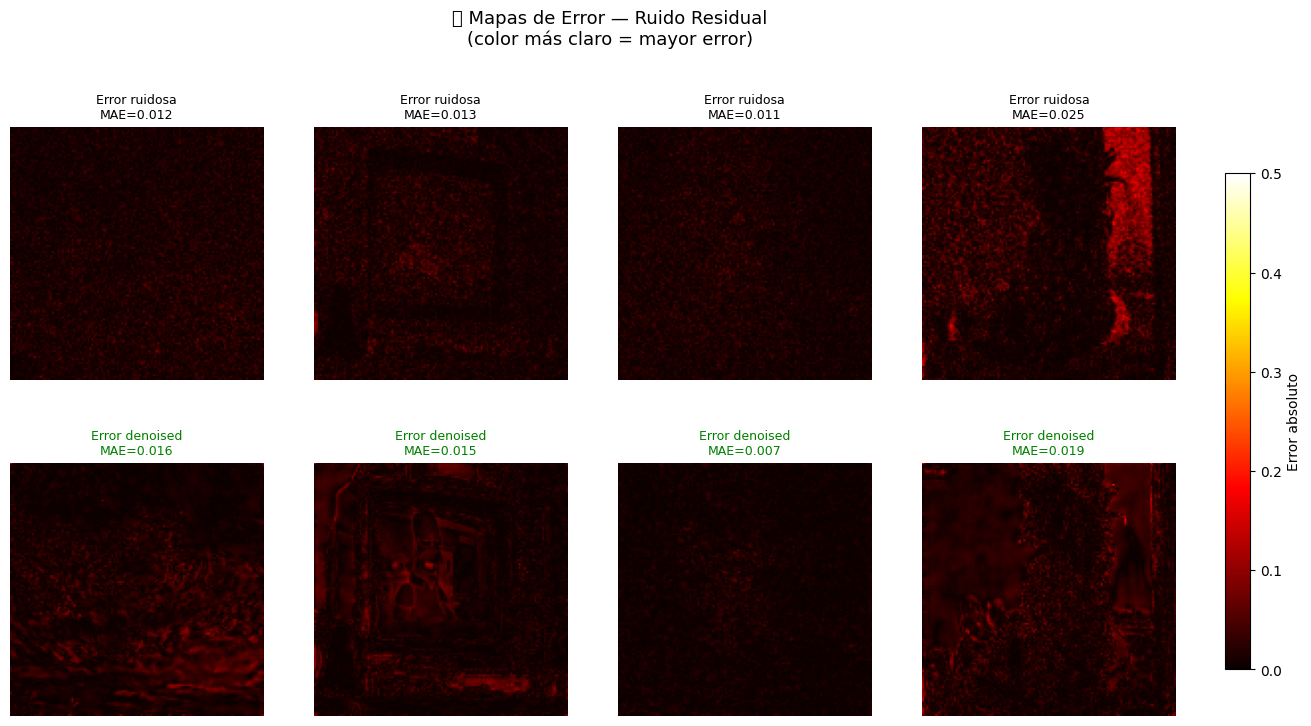

In [109]:
# ── Análisis de mapas de diferencia ──────────────────────────────────────────
@torch.no_grad()
def plot_difference_maps(model, loader, device, n=4):
    """Muestra los mapas de error antes y después del denoising."""
    noisy_b, clean_b = next(iter(loader))
    noisy_b  = noisy_b[:n].to(device)
    clean_b  = clean_b[:n]
    denoised = model(noisy_b).cpu()
    noisy_b  = noisy_b.cpu()

    fig, axes = plt.subplots(2, n, figsize=(n*4, 8))
    fig.suptitle('🗺️ Mapas de Error — Ruido Residual', fontsize=13, fontweight='bold')

    for i in range(n):
        diff_noisy    = torch.abs(clean_b[i,0] - noisy_b[i,0]).numpy()
        diff_denoised = torch.abs(clean_b[i,0] - denoised[i,0]).numpy()

        im0 = axes[0, i].imshow(diff_noisy,    cmap='hot', vmin=0, vmax=0.5)
        im1 = axes[1, i].imshow(diff_denoised, cmap='hot', vmin=0, vmax=0.5)

        axes[0, i].set_title(f'Error ruidosa\nMAE={diff_noisy.mean():.3f}', fontsize=9)
        axes[1, i].set_title(f'Error denoised\nMAE={diff_denoised.mean():.3f}', fontsize=9, color='green')
        axes[0, i].axis('off')
        axes[1, i].axis('off')

    fig.colorbar(im1, ax=axes.ravel().tolist(), fraction=0.02, pad=0.04, label='Error absoluto')
    plt.suptitle('🗺️ Mapas de Error — Ruido Residual\n(color más claro = mayor error)', fontsize=13, y=1.01)
    plt.show()


plot_difference_maps(model, val_loader, device)

Evaluando...:   0%|          | 0/2 [00:00<?, ?it/s]


═══════════════════════════════════════════════════════
          📊 EVALUACIÓN FINAL — CONJUNTO DE VALIDACIÓN
═══════════════════════════════════════════════════════
  Métrica                   Ruidosa     Denoised
-------------------------------------------------------
  PSNR (dB) ↑                 33.11        34.25
  MSE ↓                     0.00084      0.00048
  MAE ↓                     0.01734      0.01492
═══════════════════════════════════════════════════════
  Mejora PSNR: +1.13 dB
  Reducción MSE: 42.7%
═══════════════════════════════════════════════════════


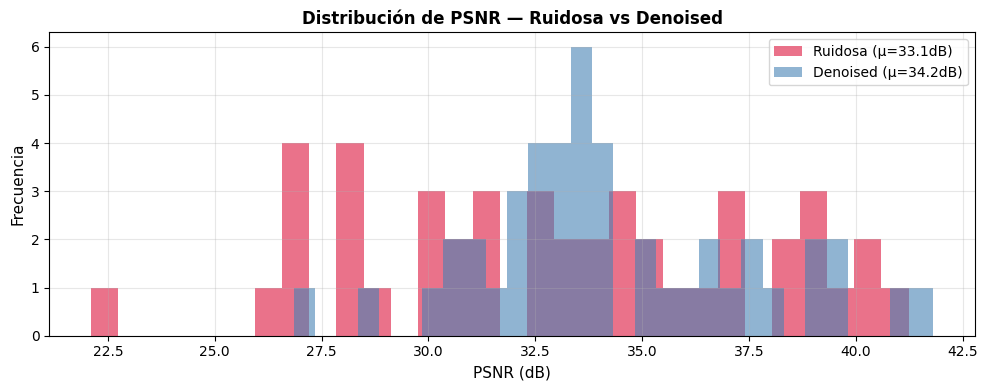

In [110]:
@torch.no_grad()
def full_evaluation(model, loader, device):
    """Evaluación completa sobre todo el conjunto de validación."""
    model.eval()

    all_psnr_noisy, all_psnr_denoised = [], []
    all_mse_noisy,  all_mse_denoised  = [], []
    all_mae_noisy,  all_mae_denoised  = [], []

    for noisy, clean in tqdm(loader, desc='Evaluando...'):
        noisy, clean = noisy.to(device), clean.to(device)
        denoised = model(noisy)

        for i in range(clean.shape[0]):
            c = clean[i].cpu().numpy().flatten()
            n = noisy[i].cpu().numpy().flatten()
            d = denoised[i].cpu().numpy().flatten()

            mse_n = np.mean((c - n)**2)
            mse_d = np.mean((c - d)**2)

            all_psnr_noisy.append(   10 * np.log10(1.0 / (mse_n + 1e-10)))
            all_psnr_denoised.append(10 * np.log10(1.0 / (mse_d + 1e-10)))
            all_mse_noisy.append(mse_n)
            all_mse_denoised.append(mse_d)
            all_mae_noisy.append(np.mean(np.abs(c - n)))
            all_mae_denoised.append(np.mean(np.abs(c - d)))

    # Tabla de resultados
    print("\n" + "═"*55)
    print("          📊 EVALUACIÓN FINAL — CONJUNTO DE VALIDACIÓN")
    print("═"*55)
    print(f"  {'Métrica':<20} {'Ruidosa':>12} {'Denoised':>12}")
    print("-"*55)
    print(f"  {'PSNR (dB) ↑':<20} {np.mean(all_psnr_noisy):>12.2f} {np.mean(all_psnr_denoised):>12.2f}")
    print(f"  {'MSE ↓':<20} {np.mean(all_mse_noisy):>12.5f} {np.mean(all_mse_denoised):>12.5f}")
    print(f"  {'MAE ↓':<20} {np.mean(all_mae_noisy):>12.5f} {np.mean(all_mae_denoised):>12.5f}")
    print("═"*55)
    print(f"  Mejora PSNR: +{np.mean(all_psnr_denoised) - np.mean(all_psnr_noisy):.2f} dB")
    print(f"  Reducción MSE: {(1 - np.mean(all_mse_denoised)/np.mean(all_mse_noisy))*100:.1f}%")
    print("═"*55)

    # Distribución de PSNR
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.hist(all_psnr_noisy,    bins=30, alpha=0.6, color='crimson',  label=f'Ruidosa (μ={np.mean(all_psnr_noisy):.1f}dB)')
    ax.hist(all_psnr_denoised, bins=30, alpha=0.6, color='steelblue',label=f'Denoised (μ={np.mean(all_psnr_denoised):.1f}dB)')
    ax.set_xlabel('PSNR (dB)', fontsize=11)
    ax.set_ylabel('Frecuencia', fontsize=11)
    ax.set_title('Distribución de PSNR — Ruidosa vs Denoised', fontsize=12, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


full_evaluation(model, val_loader, device)

# References 
Hinton, G. & Salakhutdinov, R. (2006). Reducing the Dimensionality of Data with Neural Networks. Science.

Ronneberger, O., Fischer, P., & Brox, T. (2015). U-Net: Convolutional Networks for Biomedical Image Segmentation. MICCAI.

Wang, Z. et al. (2004). Image Quality Assessment: From Error Visibility to Structural Similarity. IEEE TIP.

Zhang, K. et al. (2017). Beyond a Gaussian Denoiser: Residual Learning of Deep CNN for Image Denoising. IEEE TIP.

Dataset: Multi-Noises for Image Denoising — Kaggle